In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch import loggers as pl_loggers
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torchvision.transforms import v2
import torchvision
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torchgeo.datasets import RasterDataset, NonGeoDataset, IntersectionDataset, stack_samples, unbind_samples, random_bbox_assignment
from torchgeo.samplers import RandomGeoSampler, RandomBatchGeoSampler, GridGeoSampler
from torchgeo.datamodules import GeoDataModule
from torchgeo.datasets.utils import rgb_to_mask
import rasterio
from torchinfo import summary
import os
import re
import shutil
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import random
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import segmentation_models_pytorch as smp

In [4]:
if torch.backends.mps.is_available():
	mps_device = torch.device("mps")
	x = torch.ones(1, device=mps_device)
	print(x)
elif torch.cuda.is_available():
	cuda_device = torch.device("cuda")
	x = torch.ones(1, device=cuda_device)
	print(x)

	print(torch.cuda.get_device_name(0))
	print('Memory Usage:')
	print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
	print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
	
else:
	print("MPS device not found.")

tensor([1.], device='cuda:0')
NVIDIA GeForce RTX 3070 Laptop GPU
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


Plot Images Util

In [5]:
def plot_images(base_plot_size=4, overlay_tuples=[], cmap_labels=None, **images):
	n = len(images) + len(overlay_tuples)
	siz = base_plot_size * n
	fig, axs = plt.subplots(1,n, figsize=(siz, base_plot_size))

	for i, (name, image) in enumerate(images.items()):
		if n > 1:
			axs[i].set_title(name)
			axs[i].imshow(image)
			axs[i].axis('off')
		else:
			axs.set_title(name)
			axs.imshow(image)

	for j, overlay_tuple in enumerate(overlay_tuples):
		axs[i + j + 1].set_title(",".join(overlay_tuple))
		axs[i + j + 1].imshow(images[overlay_tuple[0]])
		axs[i + j + 1].imshow(images[overlay_tuple[1]], alpha=0.3)
		axs[i + j + 1].axis('off')
	
	if cmap_labels:
		legend_elements = [Patch(facecolor=v, label=k) for k, v in cmap_labels.items()]
		plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
		# plt.legend(handles=legend_elements)
	plt.tight_layout()
	plt.show()


def plot_overlay(image, mask, plot_size=4, cmap_labels=None):
	fig, ax = plt.subplots(1,1, figsize=(plot_size, plot_size))

	ax.imshow(image)
	ax.imshow(mask, alpha=0.3)
	ax.axis('off')

	if cmap_labels:
		legend_elements = [Patch(facecolor=v, label=k) for k, v in cmap_labels.items()]
		plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
	plt.tight_layout()



## Data loaders 

Binary Dataset Dataloaders & DataModule

In [6]:
class RGBLoader(RasterDataset):
	filename_glob = '*.tif'
	is_image=True
	separate_files=False
	# all_bands=('B01', 'B02', 'B03')
	# rgb_bands=('B01', 'B02', 'B03')

class SegmentationMapLoader(RasterDataset):
	filename_glob = '*.tif'
	is_image=False # False means is a segmentation mask
	# dtype=torch.float32 # Override to be used in pixel-wise regression
	separate_files=False

class CustomGeoDataModule(GeoDataModule): # Geodamatodule extends from torch lightning DataModules
	def __init__(self, **kwargs):
		super().__init__(
			dataset_class=kwargs['dataset_class'],
			batch_size=kwargs['batch_size'],
			patch_size=kwargs['patch_size'],
			length=kwargs['length'],
			num_workers=kwargs['num_workers'],
			**kwargs['dataset_class_kwargs']
		)
		# keep in mind that super method will set kwargs object attribute as kwargs['dataset_class_kwargs']
		self.split_faction = kwargs.get('split_fraction', [0.6, 0.2, 0.2]) # train, validate, test
		self.seed = kwargs.get('seed')

	def setup(self, stage):
		# self.dataset = self.dataset_class(**self.kwargs)
		self.dataset = self.kwargs['dataset1'] & self.kwargs['dataset2']

		generator = torch.Generator().manual_seed(self.seed)
		(self.train_dataset, self.val_dataset, self.test_dataset) = random_bbox_assignment(self.dataset, self.split_faction, generator)

		if stage in ["fit"]:
			self.train_batch_sampler = RandomBatchGeoSampler(self.train_dataset, self.patch_size, self.batch_size, self.length, )
		if stage in ["fit", "validate"]:
			self.val_sampler = GridGeoSampler(self.val_dataset, self.patch_size, self.patch_size)
		if stage in ["test"]:
			self.test_sampler = GridGeoSampler(self.test_dataset, self.patch_size, self.patch_size)

In [7]:
# Dataset root paths
imgs_path = '../datasets/train/images/'
masks_path = '../datasets/train/gt/'

patch_size=256
sample_size = 100
batch_size = 8
n_workers = 4
split_fraction = [0.8, 0.1, 0.1]

images_transforms = v2.Compose([
  v2.Resize(size=128),
  # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
segmentation_transforms = v2.Compose([v2.Resize(size=128, interpolation=torchvision.transforms.InterpolationMode.NEAREST_EXACT)])


images_dataset = RGBLoader(
  imgs_path,
  transforms=images_transforms
)
segmentation_map_dataset = SegmentationMapLoader(
  masks_path,
  transforms = segmentation_transforms
)

datamodule = CustomGeoDataModule(
	dataset_class = IntersectionDataset,
	batch_size = batch_size, # GeoDataModule kwargs
	patch_size = patch_size, # GeoDataModule kwargs
	length = sample_size, # GeoDataModule kwargs
	num_workers = n_workers, # GeoDataModule kwargs
	dataset_class_kwargs = dict(
		dataset1 = images_dataset, # IntersectionDataset kwargs
		dataset2 = segmentation_map_dataset, # IntersectionDataset kwargs
		collate_fn = stack_samples, # IntersectionDataset kwargs
	),
	split_fraction=split_fraction,
	seed=12345,
)

Converting SegmentationMapLoader res from 0.3 to 0.29999999999997673


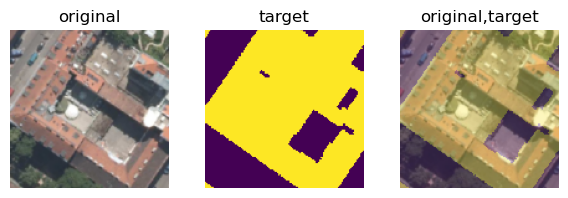

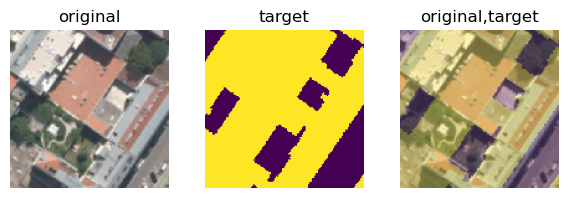

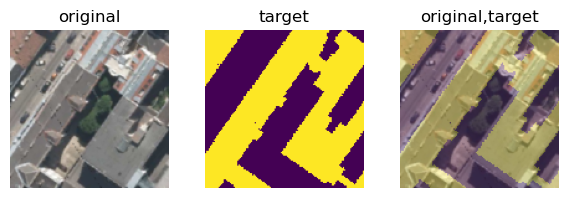

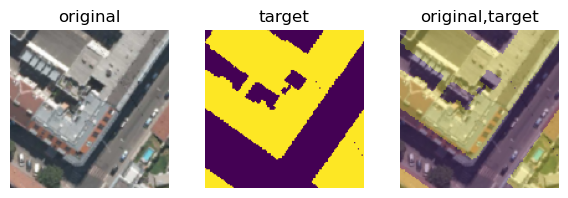

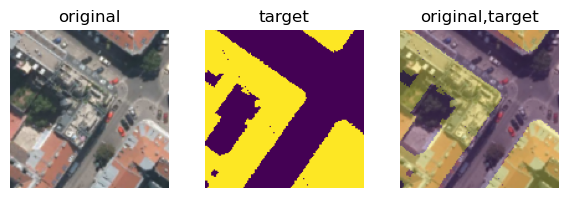

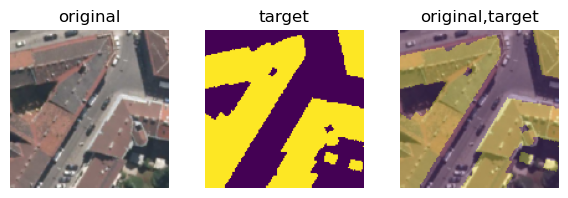

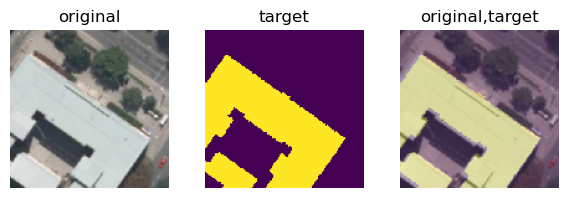

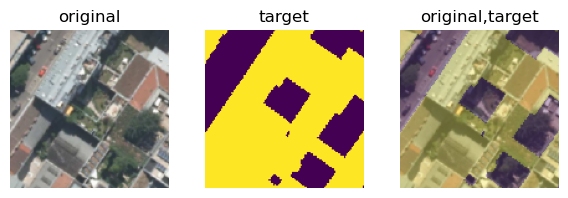

In [8]:
datamodule.setup('fit')
dataloader = datamodule.train_dataloader()
iterator = iter(dataloader)

batch = next(iterator)
images = batch['image']
masks = batch['mask']

for image, mask in zip(images, masks):
	plot_images(
		base_plot_size=2,
		original=v2.ToPILImage(mode='RGB')(image/255),
		target=mask.squeeze()/255,
		overlay_tuples=[['original', 'target']]
	)

In [9]:
images.shape, masks.shape

(torch.Size([8, 3, 128, 128]), torch.Size([8, 1, 128, 128]))

Lightning DataModule (GeoDataModule)

## Model (U-Net)

**Paper:** https://arxiv.org/pdf/1505.04597v1

**Related Readings:**
* Skip connections: https://theaisummer.com/skip-connections/
* Skip connections(cont.): https://www.analyticsvidhya.com/blog/2021/08/all-you-need-to-know-about-skip-connections/
* Segmentation Intro: https://www.jeremyjordan.me/semantic-segmentation/
* Satellital Imagery segmentation: https://towardsdatascience.com/u-net-for-semantic-segmentation-on-unbalanced-aerial-imagery-3474fa1d3e56/
* Convolution visualization: https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md (useful to see how the upsampling transposed convolution works)
* Batch Norm: https://towardsdatascience.com/batch-norm-explained-visually-how-it-works-and-why-neural-networks-need-it-b18919692739/

Other Implementations:
* https://github.com/milesial/Pytorch-UNet

Unet Architecture looks like this:

<img src="https://towardsdatascience.com/wp-content/uploads/2021/10/1eQLQo43suhzuHslqy-LL3g.png" width="800">

The key elements of a step in the "contraction" path of the architecture are:
* Double 3x3 convolutions at every step
* After the double convolutions, it has a 2x2 max pooling with stride 2 for downsampling
* After each downsample, the number of channels are doubled

The key elements of a step in the "expansive" path of the architecture are:
* 2x2 up-convolution that halves the number of channels (upscaling)
* We concatenate the corresponding feature maps of the contraction path to the upscaled maps.
  * Keep in mind that the concatenated maps are cropped because we miss border pixels on each convolution
  * Some authors handle the border issues by extending/reflecting/padding the images.
* We apply double 3x3 convolutions before the next upscaling.

At the end we apply a 1x1 convolution layer to map the resulting feature maps to the desired number of classes

In [10]:
def global_augmentations(image, mask):
	# if random.random() > 0.5:
	# 	angle = np.random.randint(4) * 90
	# 	image = v2.functional.rotate(image, angle)
	# 	mask = v2.functional.rotate(mask, angle)
	
	if random.random() > 0.5:
		image = v2.functional.vflip(image)
		mask = v2.functional.vflip(mask)
	
	if random.random() > 0.5:
		image = v2.functional.hflip(image)
		mask = v2.functional.hflip(mask)
	return image, mask

In [11]:
# Dataset root paths
imgs_path = '../datasets/train/images/'
masks_path = '../datasets/train/gt/'

patch_size=256
sample_size = 5000
batch_size = 8
n_workers = 0
split_fraction = [0.7, 0.1, 0.2]

rescale_size = 128

images_transforms = v2.Compose([
  v2.Resize(size=rescale_size),
  # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
segmentation_transforms = v2.Compose([
    v2.Resize(size=rescale_size, interpolation=torchvision.transforms.InterpolationMode.NEAREST_EXACT)
])

images_dataset = RGBLoader(
  imgs_path,
  transforms=images_transforms
)
segmentation_map_dataset = SegmentationMapLoader(
  masks_path,
  transforms = segmentation_transforms
)

datamodule = CustomGeoDataModule(
	dataset_class = IntersectionDataset,
	batch_size = batch_size, # GeoDataModule kwargs
	patch_size = patch_size, # GeoDataModule kwargs
	length = sample_size, # GeoDataModule kwargs
	num_workers = n_workers, # GeoDataModule kwargs
	dataset_class_kwargs = dict(
		dataset1 = images_dataset, # IntersectionDataset kwargs
		dataset2 = segmentation_map_dataset, # IntersectionDataset kwargs
		collate_fn = stack_samples, # IntersectionDataset kwargs
	),
	split_fraction=split_fraction,
	seed=0,
)

In [12]:
class UNetLightning(L.LightningModule):
	def __init__(
		self,
		image_size=256,
		lr=1e-3,
		epochs=30,
		testing=False
	):
		super().__init__()
		self.model = smp.Unet(
			encoder_name="resnet34",
			encoder_weights="imagenet",
			in_channels=3,  # RGB input
			classes=1,  # Binary segmentation
			
		)
		# self.save_hyperparameters()
		params = smp.encoders.get_preprocessing_params('resnet34')
		self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
		self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

		# Loss function (Dice Loss for binary segmentation)
		self.loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

		self.testing=testing
		self.image_size=image_size
		self.lr = lr
		self.epochs=epochs
		self.save_hyperparameters()

	def forward(self, image):
		image = (image - self.mean) / self.std # Normalization

		return self.model(image)

	def training_step(self, batch, batch_idx):
		image, mask = batch['image'] / 255, batch['mask'] / 255
		image, mask = global_augmentations(image, mask)
		pred_mask = self(image)

		if (self.testing):
			print("--------")
			print("mask shape:", mask.shape)
			print("image shape:", image.shape)
			print("pred mask shape:", pred_mask.shape)

		loss = self.loss_fn(pred_mask, mask)
		self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
		return loss

	def validation_step(self, batch, batch_idx):
		image, mask = batch['image'] / 255, batch['mask'] / 255
		pred_mask = self(image)
		
		loss = self.loss_fn(pred_mask, mask)
		self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
		return loss
	
	@torch.no_grad()
	def test_step(self, batch, batch_idx):
		image, mask = batch['image'] / 255, batch['mask'] / 255
		pred_mask = self(x)
		
		loss = self.loss_fn(pred_mask, mask)
		self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
		return loss
	
	def on_train_epoch_start(self):
		# Log the learning rate
		optimizer = self.trainer.optimizers[0]
		lr = optimizer.param_groups[0]['lr']
		self.log('learning_rate', lr, on_epoch=True, prog_bar=True)

	def configure_optimizers(self):
		optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
		scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
			optimizer,
			'min',
			patience=8,
			factor=0.05,
			min_lr=1e-8
		)

		return {
			"optimizer": optimizer,
			"lr_scheduler": {
					"scheduler": scheduler,
					"monitor": "val_loss",
					"frequency": 1
			},
    }


## Training

In [13]:
EPOCHS = 50
LR = 1e-4
DEV_MODE = False

In [14]:
model = UNetLightning(
  image_size=rescale_size,
	lr=LR,
	epochs=EPOCHS,
  testing=DEV_MODE
)

In [15]:
summary(model.model, (1, 3, rescale_size, rescale_size), depth=4)

Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [1, 1, 128, 128]          --
├─ResNetEncoder: 1-1                          [1, 3, 128, 128]          --
│    └─Conv2d: 2-1                            [1, 64, 64, 64]           9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 64, 64]           128
│    └─ReLU: 2-3                              [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-4                         [1, 64, 32, 32]           --
│    └─Sequential: 2-5                        [1, 64, 32, 32]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 32, 32]           --
│    │    │    └─Conv2d: 4-1                  [1, 64, 32, 32]           36,864
│    │    │    └─BatchNorm2d: 4-2             [1, 64, 32, 32]           128
│    │    │    └─ReLU: 4-3                    [1, 64, 32, 32]           --
│    │    │    └─Conv2d: 4-4                  [1, 64, 32, 32]           36,864
│    │ 

In [16]:
out_path = './finetuning_pretrained/t_5_res34/'
checkpoint_path = os.path.join(out_path, 'last.ckpt')
load_checkpoint = False

if not os.path.exists(out_path):
	os.makedirs(out_path)

logger = pl_loggers.CSVLogger(
	out_path,
	name='train_logs'
)

checkpoint_callback = ModelCheckpoint(
	every_n_epochs=1,
	dirpath=out_path,
	filename='{epoch}-{val_loss:.2f}-{train_loss:.2f}',
	save_last=True,
	save_top_k=5,
	monitor='val_loss',
	mode='min',
)

trainer = Trainer(
	max_epochs=EPOCHS,
	accelerator='cuda',
	callbacks=[checkpoint_callback, ],
	logger=logger,
	fast_dev_run=False
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [17]:
if load_checkpoint:
	print("LOAD FROM CHECKPOINT")
	trainer.fit(model=model, datamodule=datamodule, ckpt_path=checkpoint_path)
else:
	print("NEW TRAINING!!!")
	trainer.fit(model=model, datamodule=datamodule)

You are using a CUDA device ('NVIDIA GeForce RTX 3070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOAD FROM CHECKPOINT
Converting SegmentationMapLoader res from 0.3 to 0.29999999999997673


/home/edwmapa/miniconda3/envs/mlenv_nn/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/edwmapa/Git/Proj-Redes-Neuronales-2024/2_unet/finetuning_pretrained/t_5_res34 exists and is not empty.
Restoring states from the checkpoint path at ./finetuning_pretrained/t_5_res34/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | Unet     | 24.4 M | train
1 | loss_fn | DiceLoss | 0      | train
---------------------------------------------
24.4 M    Trainable params
0         Non-trainable params
24.4 M    Total params
97.745    Total estimated model params size (MB)
189       Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at ./finetuning_pretrained/t_5_res34/last.ckpt


Sanity Checking: |                                                                | 0/? [00:00<?, ?it/s]

/home/edwmapa/miniconda3/envs/mlenv_nn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/home/edwmapa/miniconda3/envs/mlenv_nn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=50` reached.


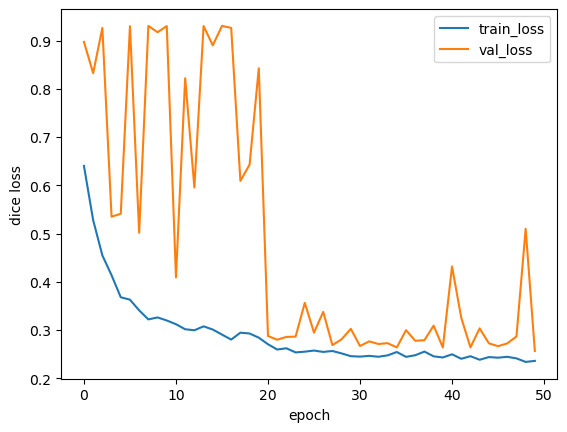

In [18]:
loss = 'loss'
df = pd.read_csv('./finetuning_pretrained/t_5_res34/train_logs/version_0/metrics.csv')
df = df.groupby(['epoch']).max().reset_index()
plt.plot(df['epoch'], df[f'train_{loss}'], label=f'train_{loss}')
plt.plot(df['epoch'], df[f'val_{loss}'], label=f'val_{loss}')

plt.ylabel('dice loss')
plt.xlabel('epoch')
plt.legend()
plt.show()


In [130]:
trainer.test(
  model=model,
  ckpt_path="best",
  datamodule=datamodule
)

Restoring states from the checkpoint path at /home/edwmapa/Git/Proj-Redes-Neuronales-2024/2_unet/finetuning_pretrained/t_5_res34/epoch=49-val_loss=0.26-train_loss=0.24.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/edwmapa/Git/Proj-Redes-Neuronales-2024/2_unet/finetuning_pretrained/t_5_res34/epoch=49-val_loss=0.26-train_loss=0.24.ckpt


Testing DataLoader 0:   0%|                                                  | 0/5597 [1:14:45<?, ?it/s]


RuntimeError: Wrong input shape height=1, width=1. Expected image height and width divisible by 32. Consider pad your images to shape (32, 32).

## Eval

In [133]:
model = UNetLightning.load_from_checkpoint(
  checkpoint_path,
  image_size=rescale_size,
	lr=LR,
	epochs=EPOCHS,
).to('cuda')
model.eval()
print(model.device)

cuda:0


In [134]:
datamodule.setup('test')
dataloader= datamodule.test_dataloader()
iterator = iter(dataloader)

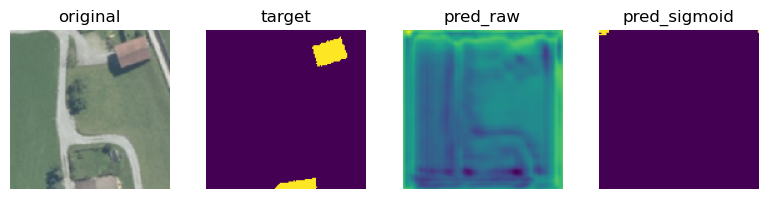

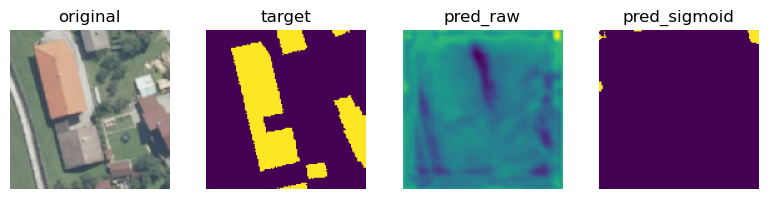

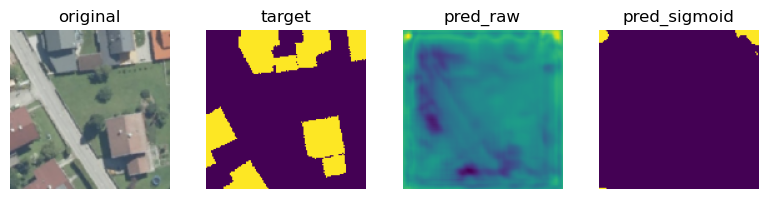

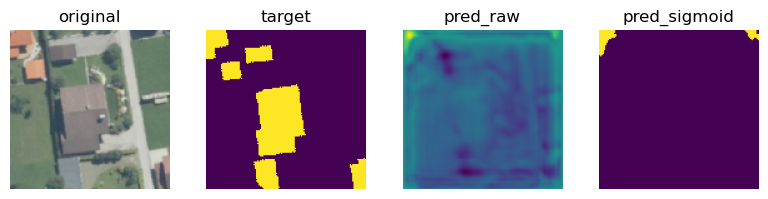

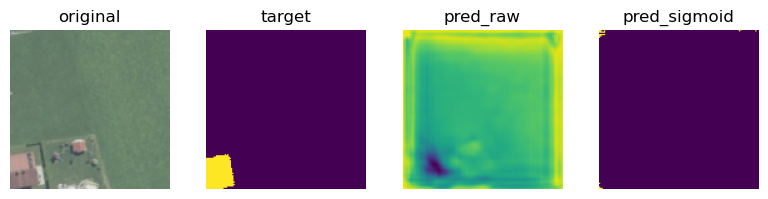

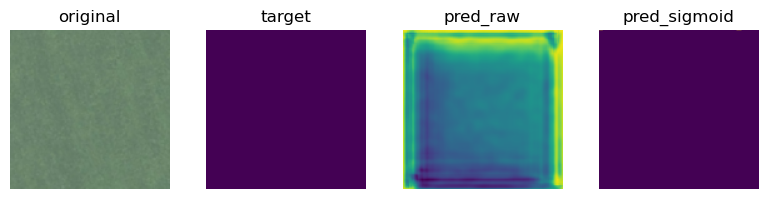

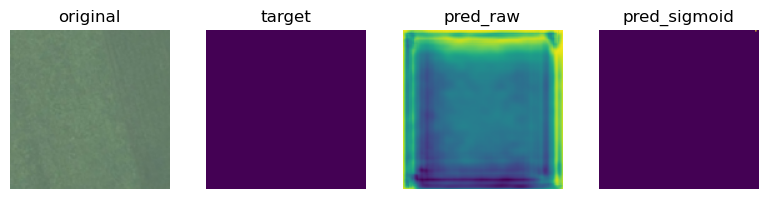

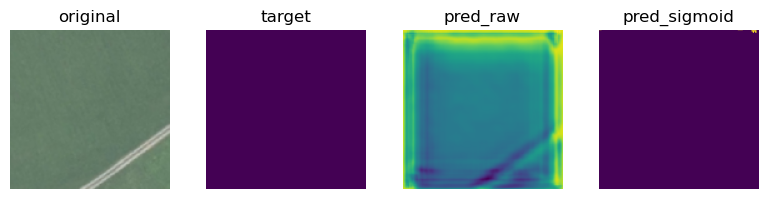

In [135]:
# TODO - Adapt
with torch.no_grad():
	batch = next(iterator)
	images = batch['image']
	masks = batch['mask']
	pred_masks = model(images.to('cuda'))

for image, mask, pred_mask in zip(images, masks, pred_masks):
	# decoded_pred = pred_mask.sigmoid(dim=2).cpu()
	# decoded_pred = (pred_mask.sigmoid() > 0.5).cpu()
	# decoded_pred = (pred_mask.flatten().sigmoid().reshape(1,128,128) > 0).float().cpu()
	decoded_pred = F.logsigmoid(pred_mask).exp().cpu()
	
	plot_images(
		base_plot_size=2,
		original=v2.ToPILImage(mode='RGB')(image/255),
		target=mask.squeeze()/255,
		pred_raw=pred_mask.cpu().squeeze(),
		pred_sigmoid=decoded_pred.squeeze()
		# overlay_tuples=[['original', 'target'], ['original', 'pred']]
	)

In [136]:
pred_mask.shape

torch.Size([1, 128, 128])

In [137]:
(pred_mask.flatten().sigmoid().reshape(1,128,128) > 0).float()

tensor([[[1., 1., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 1., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')

In [126]:
F.logsigmoid(pred_mask).exp()

tensor([[[1., 1., 0.,  ..., 1., 0., 0.],
         [1., 0., 0.,  ..., 1., 0., 1.],
         [0., 0., 0.,  ..., 1., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')